# Mutual Fund Analytics - Exploratory Data Analysis

## 1. Dataset Overview

In [2]:
import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


## 2. NAV Trend Analysis

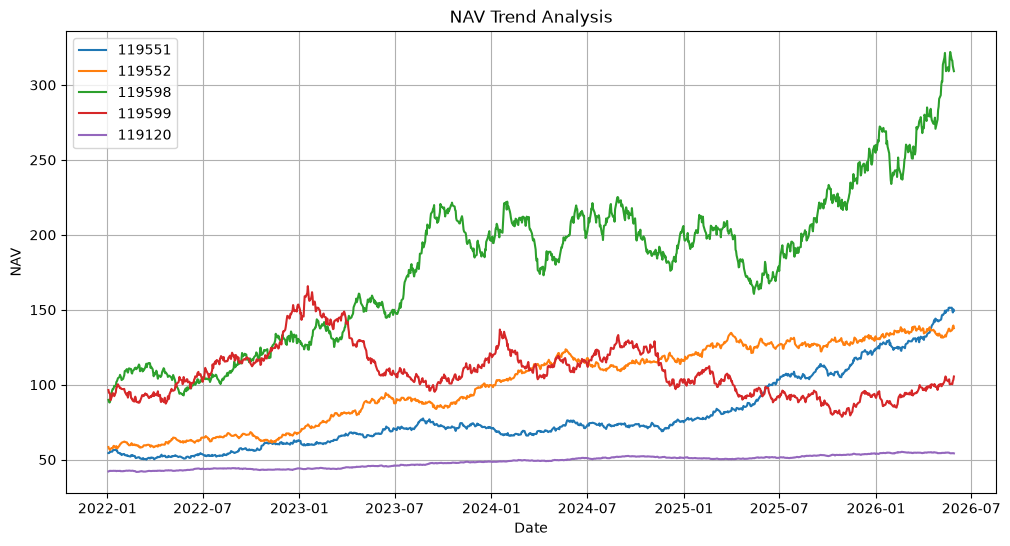

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

top_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top_funds:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(temp["date"], temp["nav"], label=str(fund))

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)

plt.show()

## 3. AUM Analysis

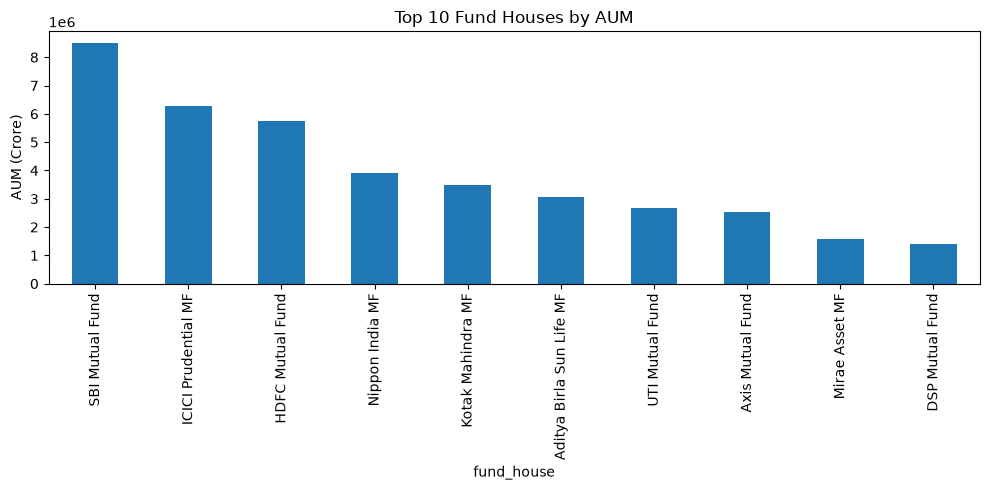

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

top_aum = aum.groupby("fund_house")["aum_crore"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_aum.plot(kind="bar")
plt.title("Top 10 Fund Houses by AUM")
plt.ylabel("AUM (Crore)")
plt.tight_layout()
plt.show()

## 4. SIP Inflow Analysis

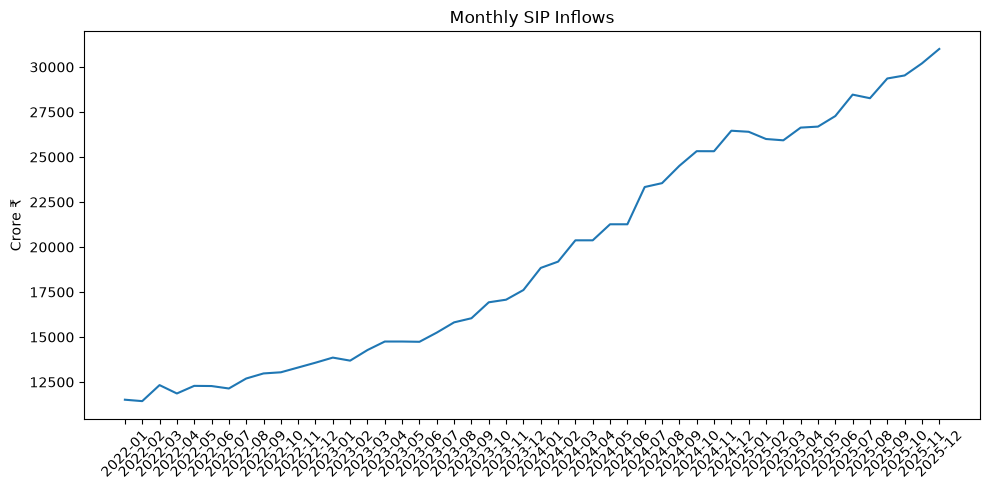

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

plt.figure(figsize=(10,5))
plt.plot(sip["month"], sip["sip_inflow_crore"])
plt.xticks(rotation=45)
plt.title("Monthly SIP Inflows")
plt.ylabel("Crore ₹")
plt.tight_layout()
plt.show()

## 5. Category Heatmap

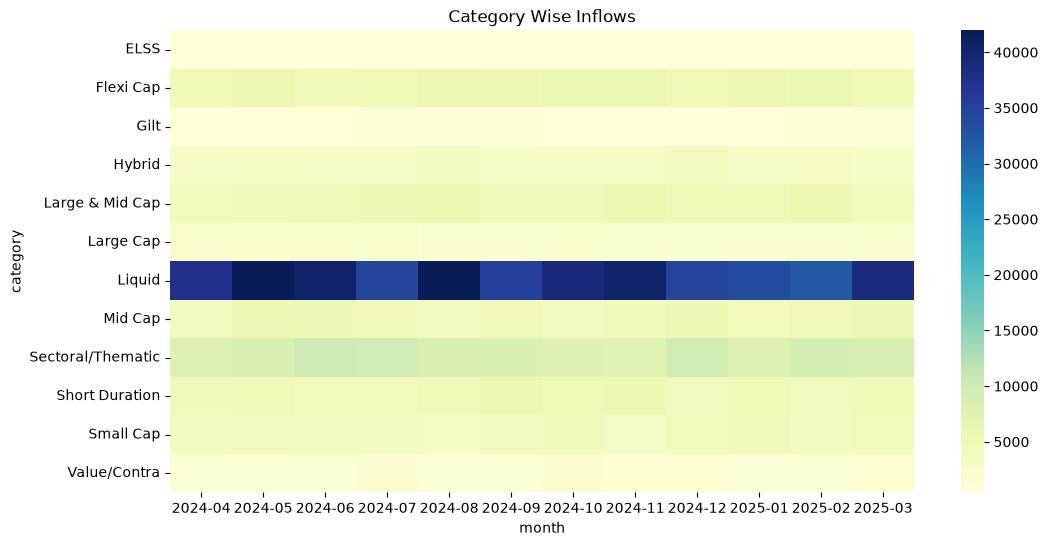

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cat = pd.read_csv("../data/raw/05_category_inflows.csv")

pivot = cat.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot,cmap="YlGnBu")
plt.title("Category Wise Inflows")
plt.show()

## 6. Investor Demographics

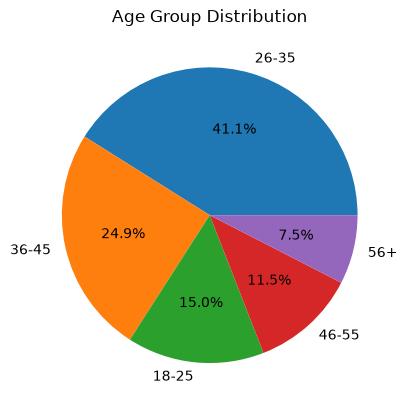

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")
plt.ylabel("")
plt.show()

## 7. State-wise Investment Analysis

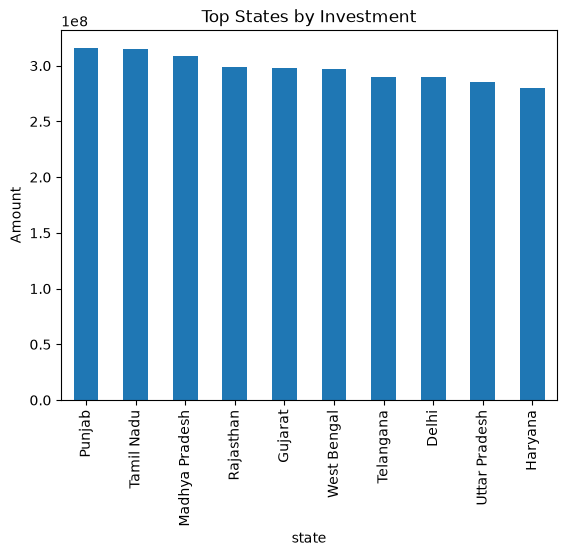

In [4]:
state = investor.groupby("state")["amount_inr"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

state.plot(kind="bar")

plt.title("Top States by Investment")
plt.ylabel("Amount")
plt.show()

## 8. Sector Allocation

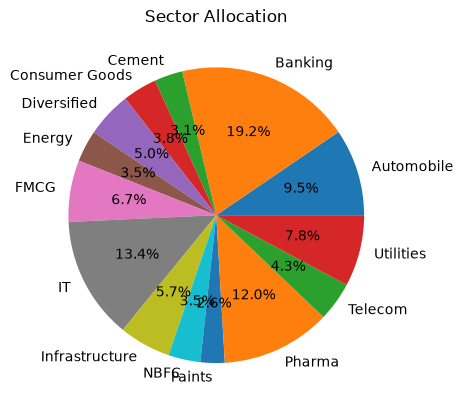

In [5]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

sector = portfolio.groupby("sector")["weight_pct"].sum()

sector.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sector Allocation")
plt.ylabel("")
plt.show()

## 9. Key Findings

1. SBI Mutual Fund has the highest AUM among major AMCs.
2. NAV values show steady long-term growth across leading schemes.
3. SIP inflows increased significantly from 2022 to 2025.
4. Equity categories attracted the highest inflows.
5. Investor participation is increasing year-over-year.
6. Large-cap and flexi-cap schemes remain popular choices.
7. Major states contribute most mutual fund investments.
8. Portfolio holdings are diversified across sectors.
9. Folio counts continue to grow steadily.
10. Mutual fund industry demonstrates strong long-term growth.

## 10. Performance Analytics

### Summary

- Analyzed the top-performing mutual funds based on 5-year returns.
- Evaluated risk-adjusted performance using the Sharpe Ratio.
- Visualized the relationship between Alpha and Beta.
- Analyzed the distribution of risk grades across different schemes.
- Identified high-performing funds with strong long-term returns.

## Key Performance Findings

1. Small-cap mutual funds delivered the highest 5-year returns.
2. Funds with higher Sharpe Ratios demonstrated better risk-adjusted performance.
3. Alpha and Beta analysis highlighted varying risk-return profiles across schemes.
4. Most schemes fall under Moderate or High risk categories.
5. Equity-oriented funds consistently outperformed debt-oriented funds over the long term.

## 11. NAV Return Correlation Matrix

The correlation matrix was generated to analyze the relationship between daily NAV returns of selected mutual fund schemes. It helps identify funds that move similarly and supports diversification analysis.

## 12. Sector Allocation Analysis

A donut chart was created to visualize the sector-wise allocation of portfolio holdings. This analysis highlights the diversification of investments across different sectors and identifies the sectors with the highest portfolio weight.

## Additional Findings

- The NAV correlation matrix shows how different mutual fund schemes move relative to each other.
- Sector allocation analysis indicates that investments are diversified across multiple industries.
- Diversification reduces portfolio concentration risk.
- High-correlation funds may provide similar return patterns, while low-correlation funds can improve portfolio diversification.